# Image analysis

example + adding fitting methods

In [1]:
from pyemittance.image import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# get example data
image = np.load("./saved_images/1618446887_img.npy", allow_pickle = True)
ncol = np.load("./saved_images/1618446887_ncol.npy", allow_pickle = True)
nrow = np.load("./saved_images/1618446887_nrow.npy", allow_pickle = True)

In [3]:
# standard way to reshape the image array
im = Image(image, ncol, nrow)
im.reshape_im()
profx, profy = im.get_im_projection()

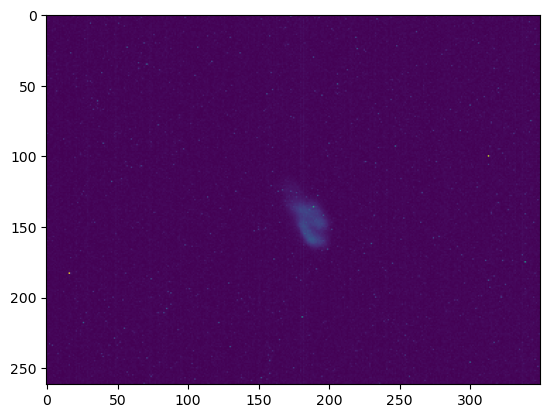

In [4]:
plt.imshow(im.proc_image)

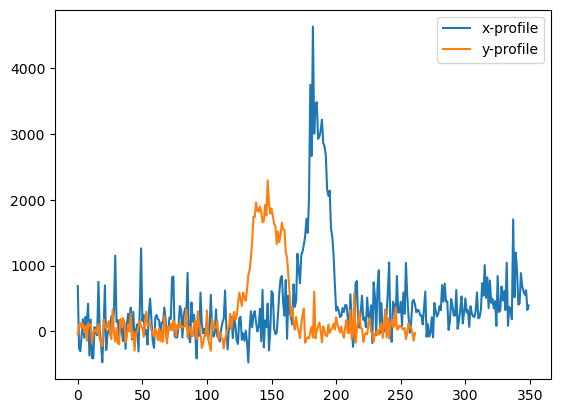

In [5]:
plt.plot(profx, label="x-profile")
plt.plot(profy, label="y-profile")
plt.legend()

### Example of how this is called in pyemittance

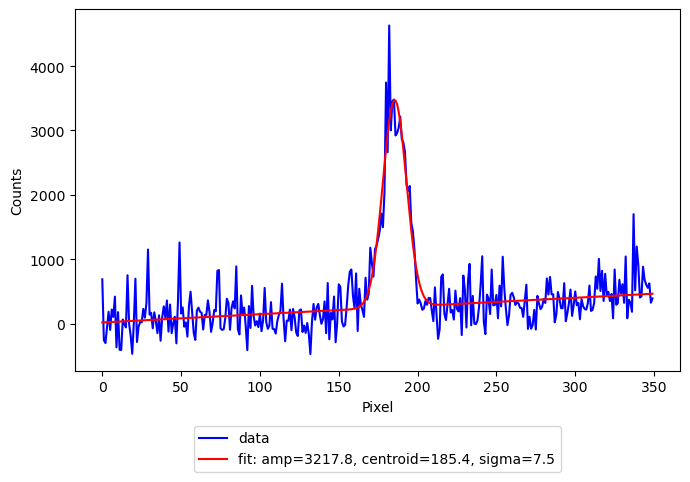

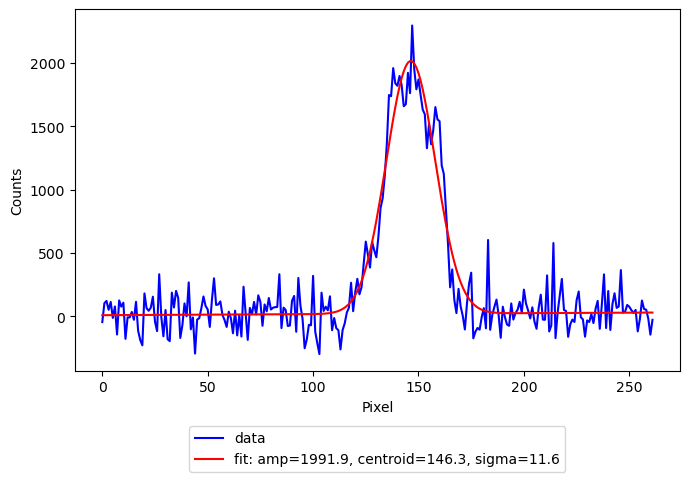

In [6]:
# returns: xsize, ysize, xsize_error, ysize_error, x_amplitude, y_amplitude
fit_res = im.get_sizes(method = "gaussian", show_plots = True)
xsize = fit_res["xrms"]
ysize = fit_res["yrms"]
xsize_error = fit_res["xrms_err"]
ysize_error = fit_res["yrms_err"]
x_amplitude = fit_res["xamp"]
y_amplitude = fit_res["yamp"]

## Gaussian + linear bg function example

In [7]:
from pyemittance.bs_fitting_methods import fit_gaussian_linear_background

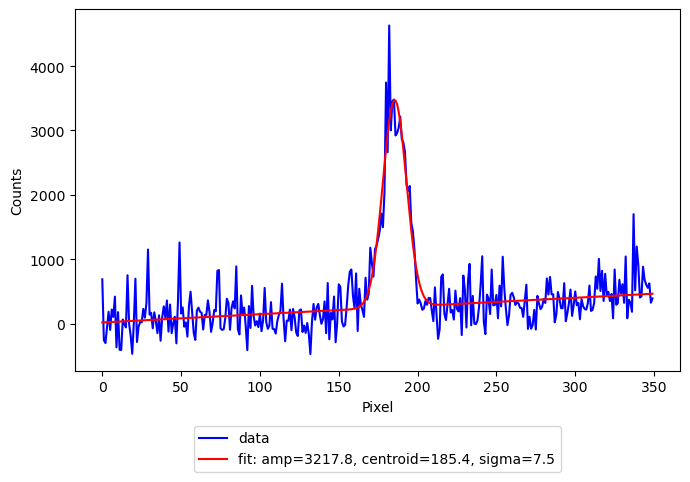

(array([3217.84266446,  185.43343034,    7.45136335]),
 array([104.61475056,   0.27784605,   0.28365575]))

In [8]:
fit_gaussian_linear_background(profx)

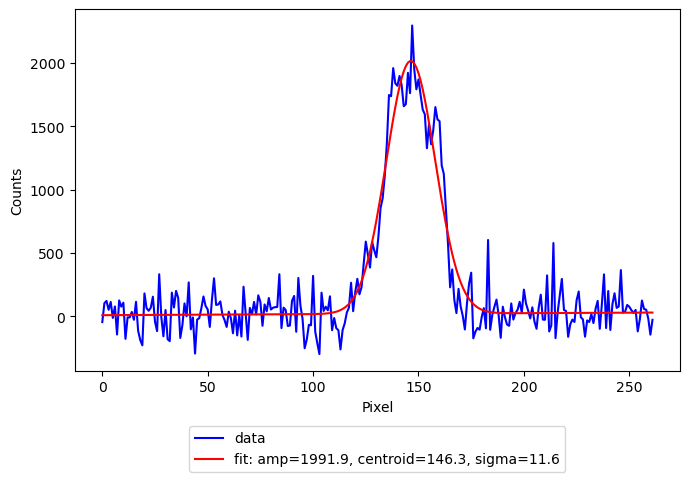

(array([1991.90020428,  146.3458308 ,   11.56409759]),
 array([44.40883482,  0.29357206,  0.30790033]))

In [9]:
fit_gaussian_linear_background(profy)

## Adding a fitting method:
### Need to write an asymmetric Gaussian + linear bg function to import as:
> fit_asym_gaussian_linear_background
### and to pass an array like in the cell above and return a fit with the results:
> size (Gaussian width), error on the size, and the amplitude